# PMSGMBY Beneficiary Analysis — Assignment 2

## SETUP — Run First

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset 
DATA_FILE = 'Assignment_2_DATA_SETS.xlsx'
df = pd.read_excel(DATA_FILE, sheet_name='Dataset')

# Friendly plot style
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')

Loaded 5,000 rows × 36 columns


---
## Section A: Data Cleaning & Exploration

### A1 — Dataset Info: Shape, Types, Nulls, % Missing

 Shape 
Rows: 5,000   Columns: 36

=== Column Types, Null Count, % Missing ===
                                           dtype  non_null  null_count  pct_missing
Application_ID                            object      5000           0         0.00
State                                     object      5000           0         0.00
DISCOM                                    object      5000           0         0.00
Special_Category_State                      bool      5000           0         0.00
Beneficiary_Category                      object      5000           0         0.00
System_Size_kW                             int64      5000           0         0.00
Benchmark_Cost_per_kW                      int64      5000           0         0.00
Market_Cost_Rs                             int64      5000           0         0.00
CFA_Sanctioned_Rs                          int64      5000           0         0.00
Application_Date                  datetime64[ns]      5000           0         0.

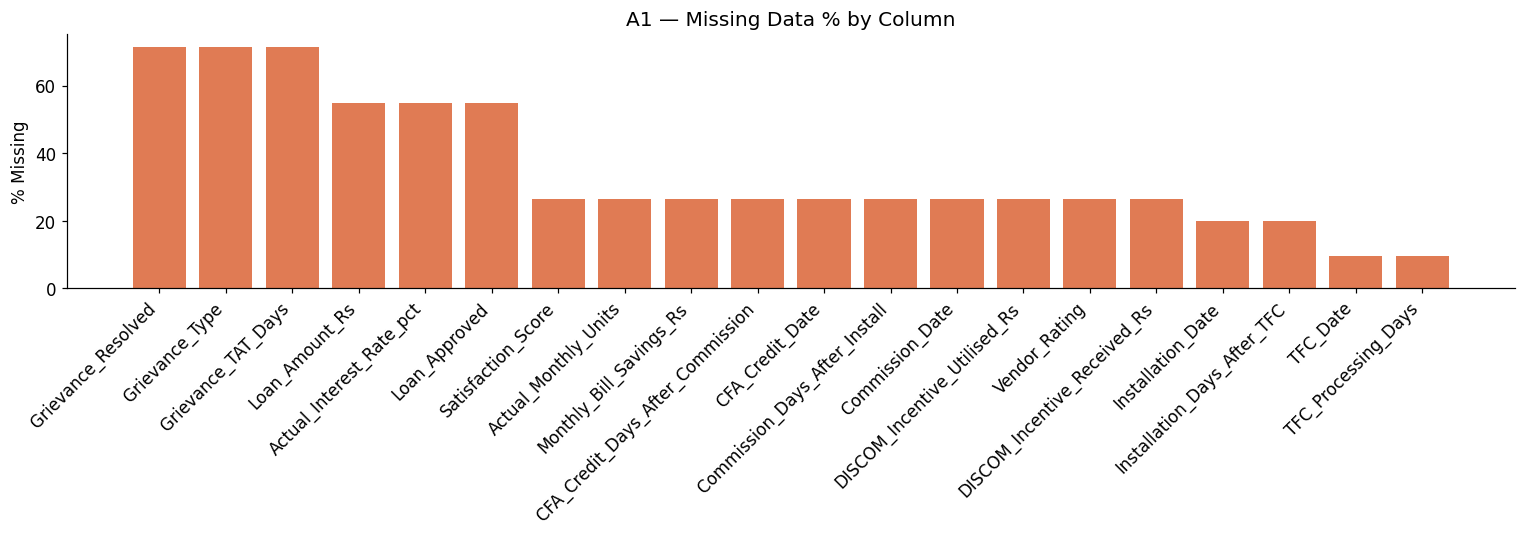

Saved → A1_Missing_Data.png


In [3]:
# A1 
print(' Shape ')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')

print('\n=== Column Types, Null Count, % Missing ===')
info_df = pd.DataFrame({
    'dtype':       df.dtypes.astype(str),
    'non_null':    df.notna().sum(),
    'null_count':  df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df.to_string())

# Visual: heatmap of missingness
fig, ax = plt.subplots(figsize=(14, 5))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
ax.bar(missing_pct.index, missing_pct.values, color='#e07b54')
ax.set_ylabel('% Missing')
ax.set_title('A1 — Missing Data % by Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('A1_Missing_Data.png', bbox_inches='tight')
plt.show()
print('Saved → A1_Missing_Data.png')

### A2 — Date Standardisation & Total Pipeline Days

Date column dtypes:
  Application_Date: datetime64[ns]
  TFC_Date: datetime64[ns]
  Installation_Date: datetime64[ns]
  Commission_Date: datetime64[ns]
  CFA_Credit_Date: datetime64[ns]

Commissioned records with pipeline days: 3,675
count    3675.0
mean      231.0
std        67.2
min        55.0
25%       183.0
50%       231.0
75%       281.0
max       422.0


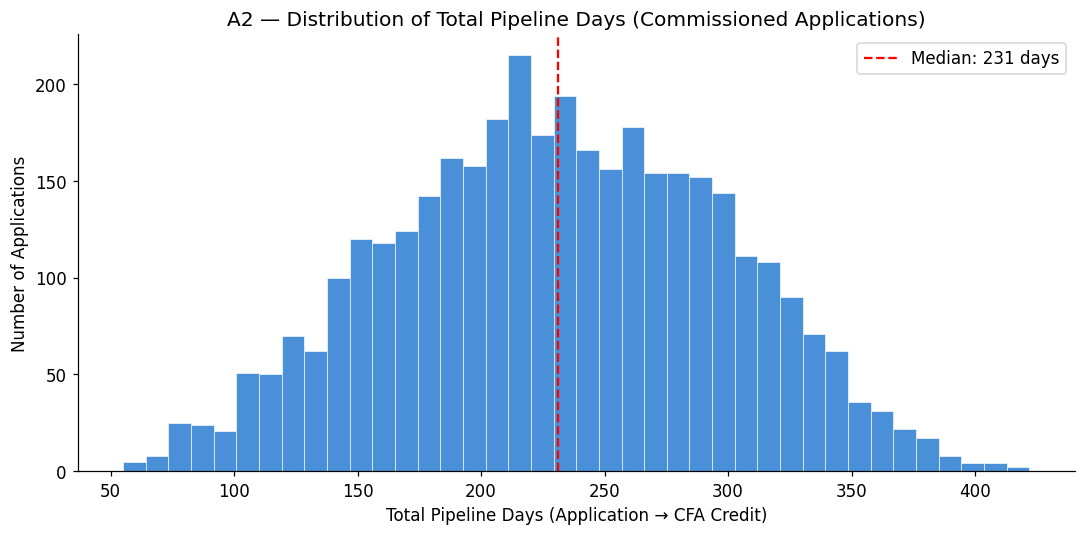

Saved → A2_Pipeline_Days_Histogram.png


In [4]:
# A2 
# Date columns are already datetime64 from Excel — confirm and compute
date_cols = ['Application_Date','TFC_Date','Installation_Date','Commission_Date','CFA_Credit_Date']
print('Date column dtypes:')
for c in date_cols:
    print(f'  {c}: {df[c].dtype}')

# Feature engineering: Total_Pipeline_Days = CFA_Credit_Date − Application_Date
df['Total_Pipeline_Days'] = (df['CFA_Credit_Date'] - df['Application_Date']).dt.days

commissioned = df[df['Commission_Date'].notna() & df['Total_Pipeline_Days'].notna()]
print(f'\nCommissioned records with pipeline days: {len(commissioned):,}')
print(commissioned['Total_Pipeline_Days'].describe().round(1).to_string())

# Histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(commissioned['Total_Pipeline_Days'], bins=40, color='#4a90d9', edgecolor='white', linewidth=0.4)
ax.axvline(commissioned['Total_Pipeline_Days'].median(), color='red', linestyle='--', label=f"Median: {commissioned['Total_Pipeline_Days'].median():.0f} days")
ax.set_xlabel('Total Pipeline Days (Application → CFA Credit)')
ax.set_ylabel('Number of Applications')
ax.set_title('A2 — Distribution of Total Pipeline Days (Commissioned Applications)')
ax.legend()
plt.tight_layout()
plt.savefig('A2_Pipeline_Days_Histogram.png', bbox_inches='tight')
plt.show()
print('Saved → A2_Pipeline_Days_Histogram.png')

### A3 — Outlier Detection & Treatment in Market_Cost_Rs

Q1=85,200  Q3=150,600  IQR=65,400
Lower bound: -12,900
Upper bound: 248,700

Outliers found: 0 (0.0%)


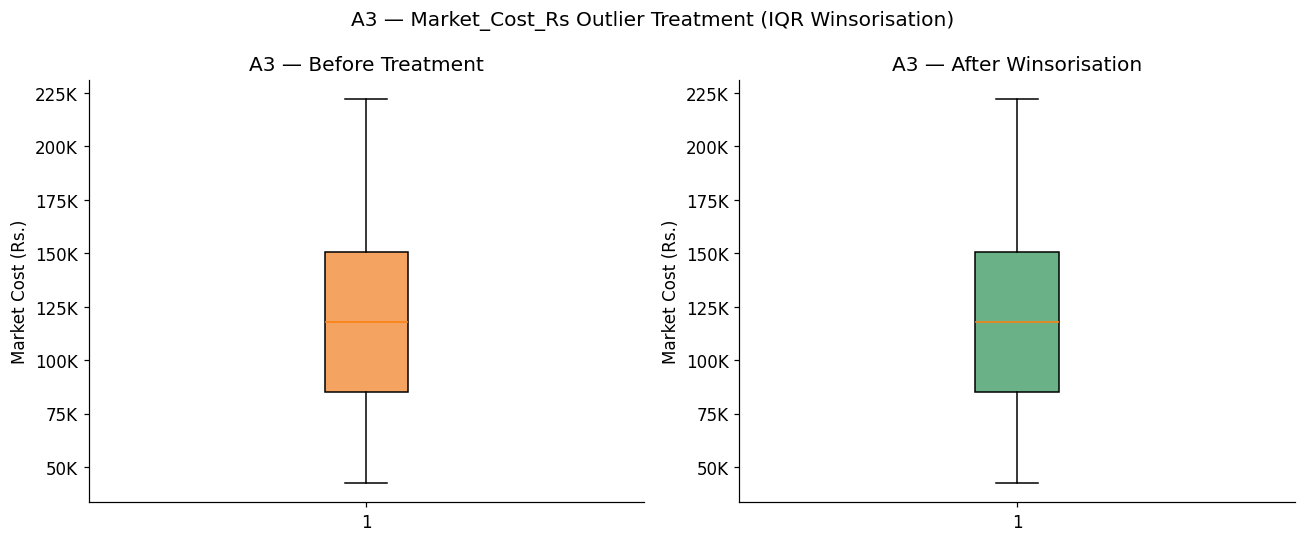

Saved → A3_Outlier_Treatment.png


In [5]:
# A3 
# IQR method: outlier threshold = Q1 - 1.5*IQR  and  Q3 + 1.5*IQR
# Justified: Market cost is right-skewed; IQR is robust to skew vs Z-score.
Q1  = df['Market_Cost_Rs'].quantile(0.25)
Q3  = df['Market_Cost_Rs'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1={Q1:,.0f}  Q3={Q3:,.0f}  IQR={IQR:,.0f}')
print(f'Lower bound: {lower_bound:,.0f}')
print(f'Upper bound: {upper_bound:,.0f}')

outlier_mask = (df['Market_Cost_Rs'] < lower_bound) | (df['Market_Cost_Rs'] > upper_bound)
print(f'\nOutliers found: {outlier_mask.sum()} ({outlier_mask.mean()*100:.1f}%)')

# Treatment: cap (Winsorise) at bounds — preserves row count for downstream analysis
df['Market_Cost_Rs_Clean'] = df['Market_Cost_Rs'].clip(lower=lower_bound, upper=upper_bound)

# Box plots before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(df['Market_Cost_Rs'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#f4a460'))
axes[0].set_title('A3 — Before Treatment')
axes[0].set_ylabel('Market Cost (Rs.)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

axes[1].boxplot(df['Market_Cost_Rs_Clean'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#6ab187'))
axes[1].set_title('A3 — After Winsorisation')
axes[1].set_ylabel('Market Cost (Rs.)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('A3 — Market_Cost_Rs Outlier Treatment (IQR Winsorisation)')
plt.tight_layout()
plt.savefig('A3_Outlier_Treatment.png', bbox_inches='tight')
plt.show()
print('Saved → A3_Outlier_Treatment.png')

### A4 — Data Integrity Checks

In [6]:
# A4 
SCHEME_CFA_MAX = 78000

# Check 1: CFA_Sanctioned_Rs > 78,000
cfa_breach = df[df['CFA_Sanctioned_Rs'] > SCHEME_CFA_MAX]
print(f'Check 1 — CFA exceeds ₹78,000 cap:')
print(f'  Breaching records: {len(cfa_breach)} ({len(cfa_breach)/len(df)*100:.2f}%)')
if len(cfa_breach) > 0:
    print(cfa_breach[['Application_ID','State','System_Size_kW','CFA_Sanctioned_Rs']].to_string(index=False))

# Check 2: Actual_Monthly_Units > Expected_Monthly_Units × 1.5
df['Units_Ratio'] = df['Actual_Monthly_Units'] / df['Expected_Monthly_Units']
units_breach = df[df['Units_Ratio'] > 1.5].dropna(subset=['Actual_Monthly_Units'])
print(f'\nCheck 2 — Actual units > 1.5× Expected:')
print(f'  Breaching records: {len(units_breach)} ({len(units_breach)/df["Actual_Monthly_Units"].notna().sum()*100:.2f}% of commissioned)')
if len(units_breach) > 0:
    print(units_breach[['Application_ID','State','Expected_Monthly_Units','Actual_Monthly_Units','Units_Ratio']].head(10).to_string(index=False))

# Flag anomalies in main dataframe
df['Anomaly_CFA_Breach']   = df['CFA_Sanctioned_Rs'] > SCHEME_CFA_MAX
df['Anomaly_Units_Excess'] = df['Units_Ratio'] > 1.5
df['Has_Anomaly']          = df['Anomaly_CFA_Breach'] | df['Anomaly_Units_Excess']
print(f'\nTotal records with any anomaly flag: {df["Has_Anomaly"].sum()}')

Check 1 — CFA exceeds ₹78,000 cap:
  Breaching records: 0 (0.00%)

Check 2 — Actual units > 1.5× Expected:
  Breaching records: 0 (0.00% of commissioned)

Total records with any anomaly flag: 0


### A5 — Summary Statistics Table

In [7]:
# A5 
stat_cols = [
    'TFC_Processing_Days',
    'CFA_Credit_Days_After_Commission',
    'Monthly_Bill_Savings_Rs',
    'Satisfaction_Score'
]

summary = df[stat_cols].agg([
    'mean', 'median',
    lambda x: x.std(),
    'min', 'max',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
]).T

summary.columns = ['Mean','Median','Std Dev','Min','Max','P25','P75']
summary = summary.round(2)

print(' A5 — Summary Statistics =')
print(summary.to_string())

# Export to styled Excel
with pd.ExcelWriter('A5_Summary_Statistics.xlsx', engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Summary')
print('\nSaved → A5_Summary_Statistics.xlsx')

 A5 — Summary Statistics =
                                     Mean   Median  Std Dev     Min      Max     P25      P75
TFC_Processing_Days                 48.06    49.00    25.01    5.00    90.00   26.00    70.00
CFA_Credit_Days_After_Commission    93.02    93.00    51.05    7.00   180.00   48.00   138.00
Monthly_Bill_Savings_Rs           1486.69  1389.17   699.56  327.92  3704.51  934.12  1939.84
Satisfaction_Score                   3.37     3.40     0.95    1.00     5.00    2.70     4.10

Saved → A5_Summary_Statistics.xlsx


---
## Section B: Financial Architecture Analysis

### B1 — Market Cost Gap % vs Benchmark

% applications with market cost > 20% above benchmark: 30.0%
count    5000.00
mean       10.13
std        14.37
min       -15.00
25%        -2.21
50%        10.20
75%        22.46
max        35.00


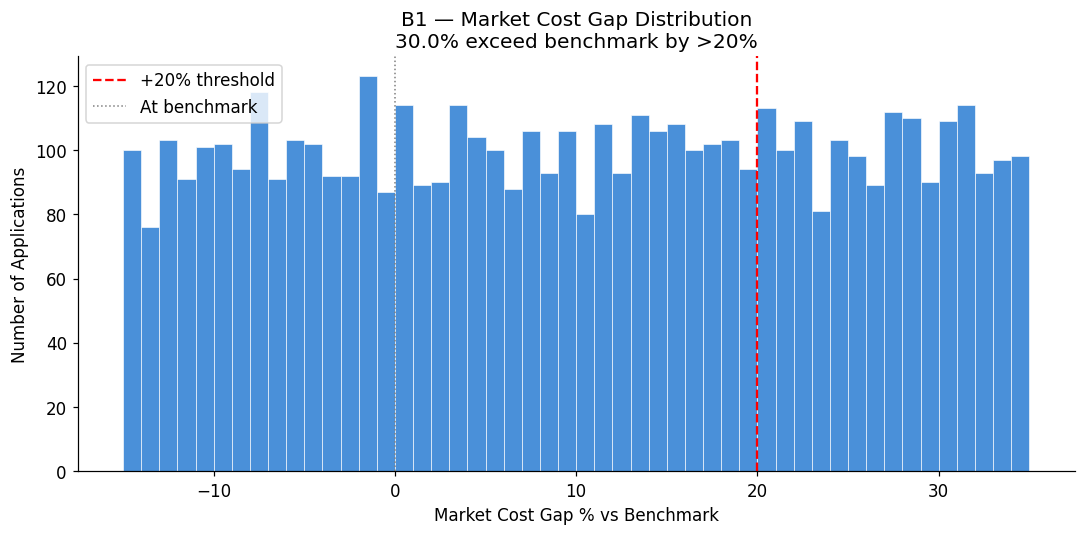

Saved → B1_Market_Cost_Gap.png


In [8]:
# B1 
df['Benchmark_Total_Cost'] = df['Benchmark_Cost_per_kW'] * df['System_Size_kW']
df['Market_Cost_Gap_Pct']  = (
    (df['Market_Cost_Rs'] - df['Benchmark_Total_Cost']) / df['Benchmark_Total_Cost'] * 100
)

above_20_pct = (df['Market_Cost_Gap_Pct'] > 20).mean() * 100
print(f'% applications with market cost > 20% above benchmark: {above_20_pct:.1f}%')
print(df['Market_Cost_Gap_Pct'].describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Market_Cost_Gap_Pct'], bins=50, color='#4a90d9', edgecolor='white', linewidth=0.4)
ax.axvline(20, color='red', linestyle='--', linewidth=1.5, label='+20% threshold')
ax.axvline(0,  color='gray', linestyle=':',  linewidth=1,   label='At benchmark')
ax.set_xlabel('Market Cost Gap % vs Benchmark')
ax.set_ylabel('Number of Applications')
ax.set_title(f'B1 — Market Cost Gap Distribution\n{above_20_pct:.1f}% exceed benchmark by >20%')
ax.legend()
plt.tight_layout()
plt.savefig('B1_Market_Cost_Gap.png', bbox_inches='tight')
plt.show()
print('Saved → B1_Market_Cost_Gap.png')

### B2 — Loan Interest Rate Distribution & Mandate Compliance

In [ ]:
# B2 
INTEREST_MANDATE = 7.0
loan_df = df[df['Has_Loan'] == True].copy()
print(f'Total loan applicants: {len(loan_df):,}')
print(f'With interest rate data: {loan_df["Actual_Interest_Rate_pct"].notna().sum():,}')

loan_valid = loan_df.dropna(subset=['Actual_Interest_Rate_pct'])
above_mandate = (loan_valid['Actual_Interest_Rate_pct'] > INTEREST_MANDATE).mean() * 100
print(f'\n% charged above mandated {INTEREST_MANDATE}%: {above_mandate:.1f}%')

# State-level breakdown
state_breach = (
    loan_valid.groupby('State')
    .apply(lambda x: (x['Actual_Interest_Rate_pct'] > INTEREST_MANDATE).mean() * 100)
    .reset_index(name='Pct_Above_Mandate')
    .sort_values('Pct_Above_Mandate', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e05c5c' if v > 20 else '#4a90d9' for v in state_breach['Pct_Above_Mandate']]
ax.barh(state_breach['State'], state_breach['Pct_Above_Mandate'], color=colors)
ax.axvline(20, color='red', linestyle='--', linewidth=1, label='>20% breach line')
ax.set_xlabel('% Borrowers Above 7% Mandate')
ax.set_title('B2 — States by % Loan Applicants Charged Above 7% Mandate')
ax.legend()
plt.tight_layout()
plt.savefig('B2_Interest_Rate_Breach_By_State.png', bbox_inches='tight')
plt.show()
print('Saved → B2_Interest_Rate_Breach_By_State.png')

### B3 — DBT SLA Compliance & DISCOM Performance

In [9]:
# B3 
DBT_SLA = 30
commissioned_df = df[df['CFA_Credit_Days_After_Commission'].notna()].copy()

overall_sla = (commissioned_df['CFA_Credit_Days_After_Commission'] <= DBT_SLA).mean() * 100
print(f'Overall % within 30-day DBT SLA: {overall_sla:.1f}%')

discom_sla = (
    commissioned_df.groupby('DISCOM')
    .agg(
        Pct_Within_SLA   = ('CFA_Credit_Days_After_Commission', lambda x: (x <= DBT_SLA).mean() * 100),
        Avg_Lag_Days     = ('CFA_Credit_Days_After_Commission', 'mean'),
        Applications     = ('CFA_Credit_Days_After_Commission', 'count')
    )
    .round(1)
    .sort_values('Pct_Within_SLA')
    .reset_index()
)

print('\n DISCOM SLA Compliance Table =')
print(discom_sla.to_string(index=False))
print('\n Top 5 Worst DISCOMs (lowest SLA %) ')
print(discom_sla.head(5).to_string(index=False))

with pd.ExcelWriter('B3_DISCOM_SLA.xlsx', engine='openpyxl') as writer:
    discom_sla.to_excel(writer, sheet_name='DISCOM_SLA', index=False)
print('Saved → B3_DISCOM_SLA.xlsx')

Overall % within 30-day DBT SLA: 14.5%

 DISCOM SLA Compliance Table =
  DISCOM  Pct_Within_SLA  Avg_Lag_Days  Applications
  PuVVNL             4.7         108.5            43
   UGVCL             8.5          94.2            47
 APEPDCL             9.5          94.4            95
  TPNODL            10.1          93.9            79
  CSPDCL            10.9          90.6           184
   APDCL            11.4          94.4           167
   DHBVN            12.4          94.6            89
  MSEDCL            12.4          82.5            89
    UPCL            12.4          92.2           217
 APSPDCL            12.5         102.4            88
 TSNPDCL            12.6          90.6            95
  JDVVNL            13.8          88.1            58
   PSPCL            13.9          99.3           202
    MPEZ            14.0          98.6           100
   MGVCL            14.3          90.1            42
   PGVCL            14.3          89.4            42
  BESCOM            14.3    

### B4 — Bill Savings by System Size & Beneficiary Category

By System Size (kW):
 System_Size_kW  Avg_Savings
              1   709.818269
              2  1416.953235
              3  2141.718969

By Beneficiary Category:
Beneficiary_Category
BPL             1463.45
SC/ST           1569.33
Women-headed    1515.46
OBC             1473.69
General         1467.01


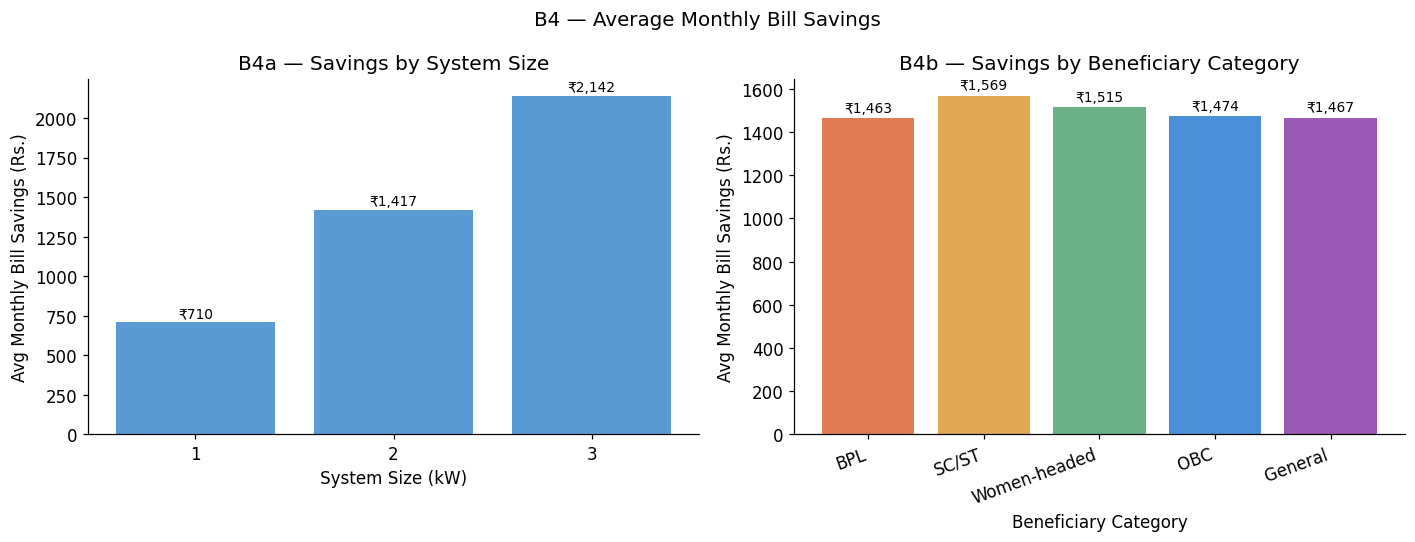

Saved → B4_Bill_Savings.png


In [10]:
# B4 
savings_df = df.dropna(subset=['Monthly_Bill_Savings_Rs'])

# (a) By System Size
by_size = savings_df.groupby('System_Size_kW')['Monthly_Bill_Savings_Rs'].mean().reset_index()
by_size.columns = ['System_Size_kW','Avg_Savings']
print('By System Size (kW):')
print(by_size.to_string(index=False))

# (b) By Beneficiary Category
cat_order = ['BPL','SC/ST','Women-headed','OBC','General']
by_cat = savings_df.groupby('Beneficiary_Category')['Monthly_Bill_Savings_Rs'].mean()
by_cat = by_cat.reindex([c for c in cat_order if c in by_cat.index])
print('\nBy Beneficiary Category:')
print(by_cat.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar([str(k) for k in by_size['System_Size_kW']], by_size['Avg_Savings'], color='#5b9bd5')
axes[0].set_xlabel('System Size (kW)')
axes[0].set_ylabel('Avg Monthly Bill Savings (Rs.)')
axes[0].set_title('B4a — Savings by System Size')
for i, v in enumerate(by_size['Avg_Savings']):
    axes[0].text(i, v + 30, f'₹{v:,.0f}', ha='center', fontsize=9)

colors_cat = ['#e07b54','#e0a854','#6ab187','#4a90d9','#9b59b6']
axes[1].bar(by_cat.index, by_cat.values, color=colors_cat[:len(by_cat)])
axes[1].set_xlabel('Beneficiary Category')
axes[1].set_ylabel('Avg Monthly Bill Savings (Rs.)')
axes[1].set_title('B4b — Savings by Beneficiary Category')
for i, v in enumerate(by_cat.values):
    axes[1].text(i, v + 30, f'₹{v:,.0f}', ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right')

plt.suptitle('B4 — Average Monthly Bill Savings', fontsize=13)
plt.tight_layout()
plt.savefig('B4_Bill_Savings.png', bbox_inches='tight')
plt.show()
print('Saved → B4_Bill_Savings.png')

### B5 — DISCOM Incentive Utilisation & Correlation with TFC Processing

DISCOMs underutilising (<80%): 36
  DISCOM  Utilisation_Rate  Avg_TFC_Days
  TPNODL             72.19     46.113924
 WBSEDCL             72.19     46.305389
   PVVNL             72.92     44.180000
   DGVCL             73.10     44.957447
  HPSEBL             73.19     49.783951
 TSSPDCL             73.22     47.764706
   MGVCL             73.24     53.238095
 TSNPDCL             73.28     48.357895
 APEPDCL             73.56     49.684211
    KSEB             74.33     47.529412
    UPCL             74.35     49.004608
  BESCOM             74.39     44.461538
   UHBVN             74.43     49.839080
   MVVNL             74.86     51.431373
   JBVNL             74.96     49.601124
   DHBVN             75.11     47.752809
   JVVNL             75.13     47.261538
  TPSODL             75.13     46.625000
  MSEDCL             75.23     49.876404
  MESCOM             75.27     47.636364
   PSPCL             75.33     46.000000
  CSPDCL             75.63     48.548913
  SBPDCL             75

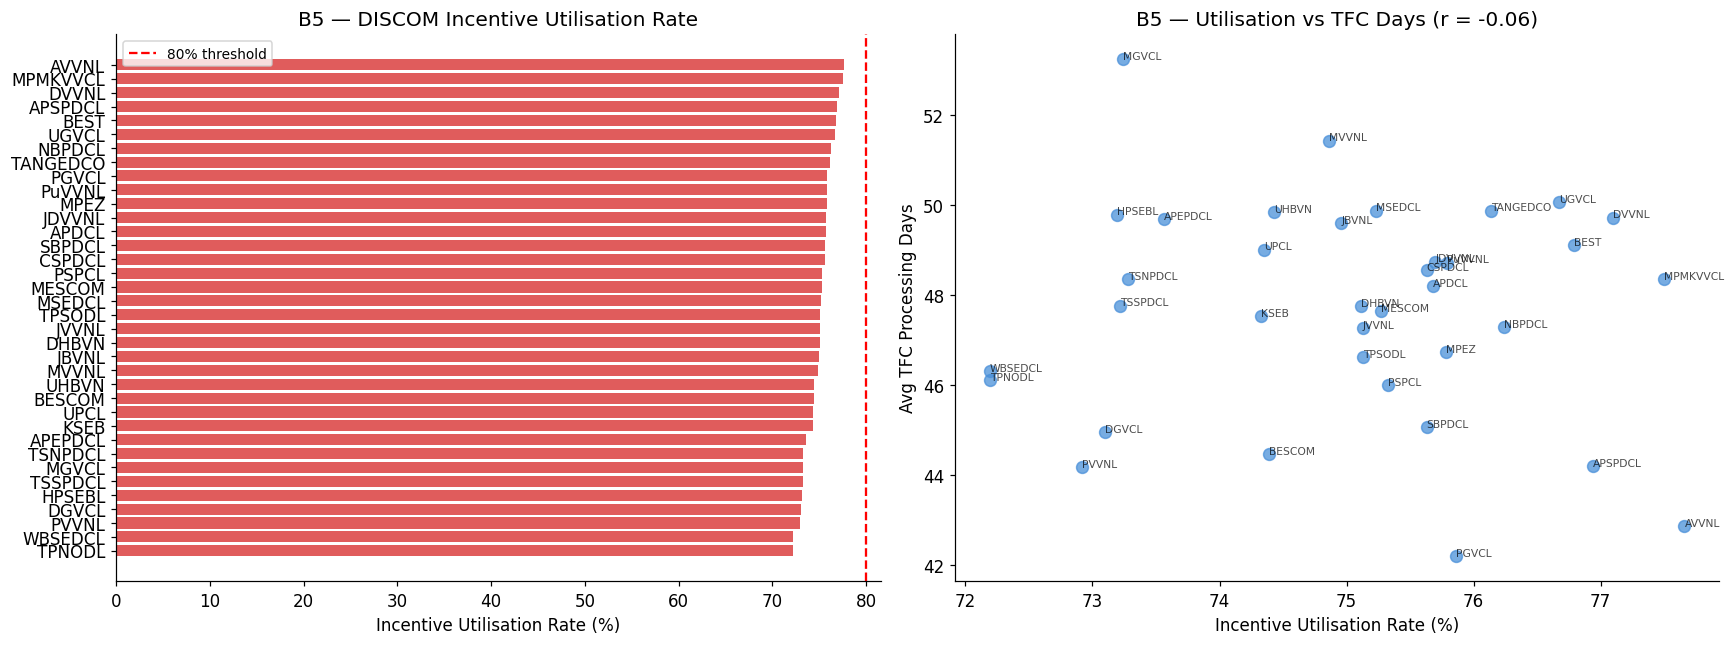

Correlation (Utilisation Rate vs TFC Days): -0.063
Saved → B5_DISCOM_Incentive.png


In [11]:
# B5 
incentive_df = df.dropna(subset=['DISCOM_Incentive_Received_Rs','DISCOM_Incentive_Utilised_Rs'])

discom_incent = (
    incentive_df.groupby('DISCOM')
    .agg(
        Total_Received = ('DISCOM_Incentive_Received_Rs','sum'),
        Total_Utilised = ('DISCOM_Incentive_Utilised_Rs','sum'),
        Avg_TFC_Days   = ('TFC_Processing_Days','mean')
    )
    .reset_index()
)
discom_incent['Utilisation_Rate'] = (discom_incent['Total_Utilised'] / discom_incent['Total_Received'] * 100).round(2)
discom_incent = discom_incent.sort_values('Utilisation_Rate')

underutil = discom_incent[discom_incent['Utilisation_Rate'] < 80]
print(f'DISCOMs underutilising (<80%): {len(underutil)}')
print(underutil[['DISCOM','Utilisation_Rate','Avg_TFC_Days']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar — utilisation rate
colors = ['#e05c5c' if v < 80 else '#6ab187' for v in discom_incent['Utilisation_Rate']]
axes[0].barh(discom_incent['DISCOM'], discom_incent['Utilisation_Rate'], color=colors)
axes[0].axvline(80, color='red', linestyle='--', label='80% threshold')
axes[0].set_xlabel('Incentive Utilisation Rate (%)')
axes[0].set_title('B5 — DISCOM Incentive Utilisation Rate')
axes[0].legend(fontsize=9)

# Scatter — utilisation vs TFC processing days
valid_corr = discom_incent.dropna(subset=['Avg_TFC_Days'])
axes[1].scatter(valid_corr['Utilisation_Rate'], valid_corr['Avg_TFC_Days'],
                alpha=0.75, color='#4a90d9', s=60)
for _, row in valid_corr.iterrows():
    axes[1].annotate(row['DISCOM'], (row['Utilisation_Rate'], row['Avg_TFC_Days']),
                     fontsize=7, alpha=0.7)
corr_val = valid_corr[['Utilisation_Rate','Avg_TFC_Days']].corr().iloc[0,1]
axes[1].set_xlabel('Incentive Utilisation Rate (%)')
axes[1].set_ylabel('Avg TFC Processing Days')
axes[1].set_title(f'B5 — Utilisation vs TFC Days (r = {corr_val:.2f})')

plt.tight_layout()
plt.savefig('B5_DISCOM_Incentive.png', bbox_inches='tight')
plt.show()
print(f'Correlation (Utilisation Rate vs TFC Days): {corr_val:.3f}')
print('Saved → B5_DISCOM_Incentive.png')

---
## Section C: Implementation Pipeline Analysis

### C1 — Pipeline Funnel Analysis

=== Pipeline Funnel ===
  Applications Filed         5,000
  Reached TFC                4,518  (↓ 9.6% drop-off from previous)
  Reached Installation       4,006  (↓ 11.3% drop-off from previous)
  Commissioned               3,675  (↓ 8.3% drop-off from previous)
  CFA Credited               3,675


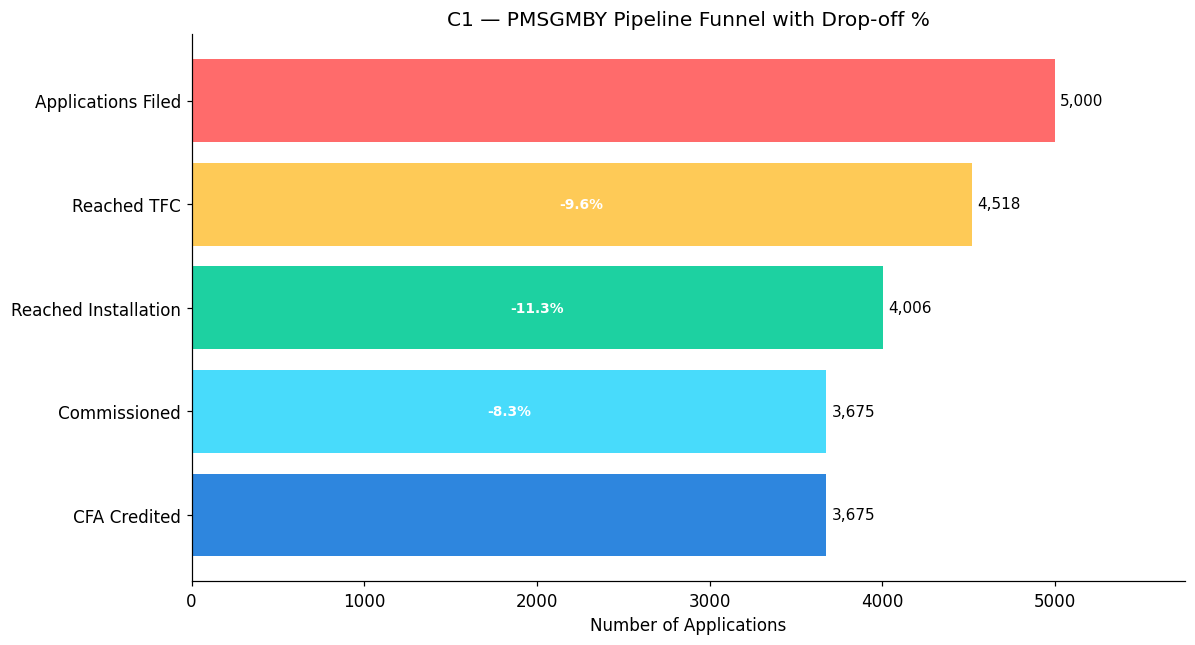

Saved → C1_Pipeline_Funnel.png


In [12]:
# C1 
stages = [
    ('Applications Filed',  len(df)),
    ('Reached TFC',         df['TFC_Date'].notna().sum()),
    ('Reached Installation',df['Installation_Date'].notna().sum()),
    ('Commissioned',        df['Commission_Date'].notna().sum()),
    ('CFA Credited',        df['CFA_Credit_Date'].notna().sum()),
]
stage_names  = [s[0] for s in stages]
stage_counts = [s[1] for s in stages]

dropoff = [0] + [
    round((stage_counts[i-1] - stage_counts[i]) / stage_counts[i-1] * 100, 1)
    for i in range(1, len(stage_counts))
]

print('=== Pipeline Funnel ===')
for name, count, drop in zip(stage_names, stage_counts, dropoff):
    drop_str = f'  (↓ {drop}% drop-off from previous)' if drop > 0 else ''
    print(f'  {name:<26} {count:>5,}{drop_str}')

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(stage_names[::-1], stage_counts[::-1],
               color=['#2e86de','#48dbfb','#1dd1a1','#feca57','#ff6b6b'])
for bar, count, drop in zip(bars, stage_counts[::-1], dropoff[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=10)
    if drop > 0:
        ax.text(bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                f'-{drop}%', va='center', ha='center', color='white', fontsize=9, fontweight='bold')
ax.set_xlabel('Number of Applications')
ax.set_title('C1 — PMSGMBY Pipeline Funnel with Drop-off %')
ax.set_xlim(0, max(stage_counts) * 1.15)
plt.tight_layout()
plt.savefig('C1_Pipeline_Funnel.png', bbox_inches='tight')
plt.show()
print('Saved → C1_Pipeline_Funnel.png')

### C2 — Average Days per Stage by State (Stacked Bar)

State with longest total average pipeline: Andhra Pradesh
  Total avg days: 236.9

                  TFC_Processing_Days  Installation_Days_After_TFC  Commission_Days_After_Install  CFA_Credit_Days_After_Commission
State                                                                                                                              
Andhra Pradesh                   48.0                         68.0                           22.6                              98.3
Haryana                          49.3                         68.9                           22.9                              94.2
Assam                            48.9                         67.5                           24.2                              94.4
Uttar Pradesh                    47.6                         64.8                           24.2                              97.5
Punjab                           46.5                         64.2                           23.9                            

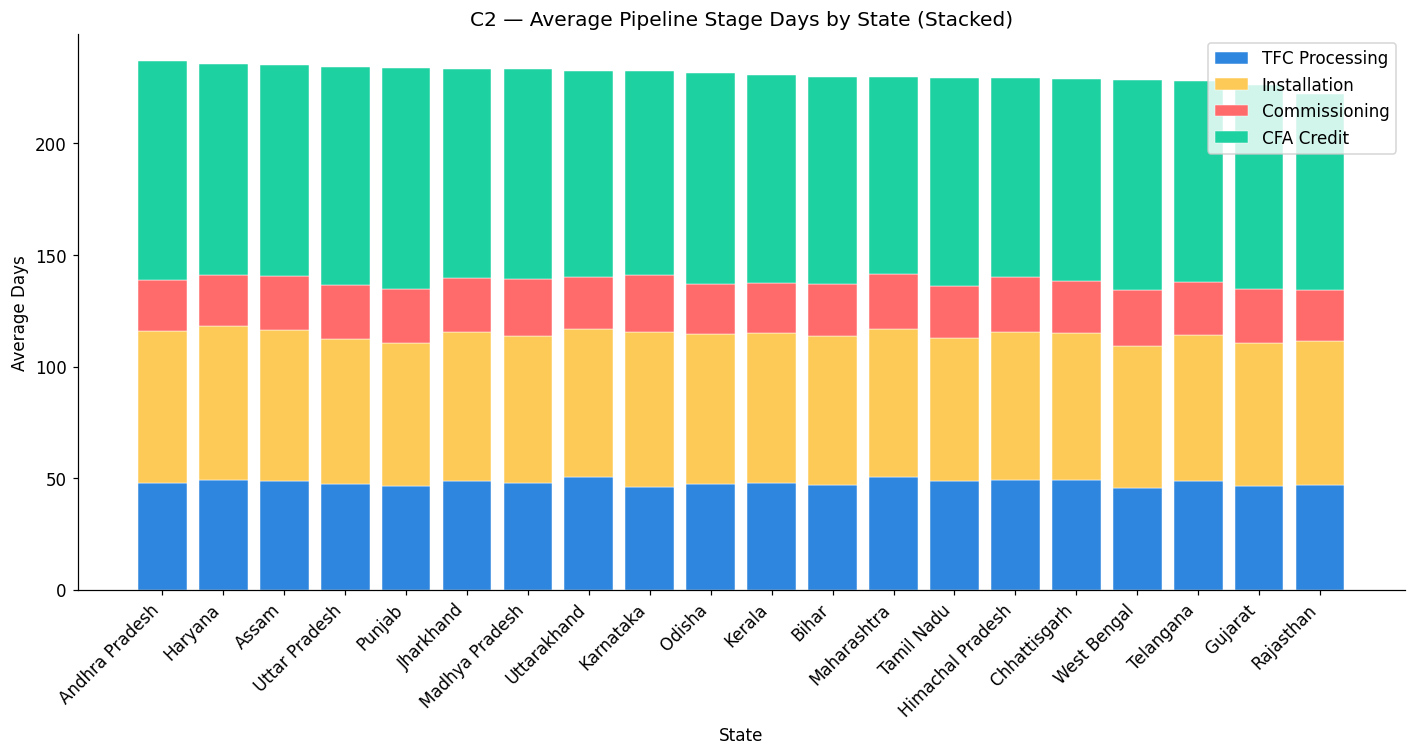

Saved → C2_Pipeline_By_State.png


In [13]:
# C2 
pipeline_cols = [
    'TFC_Processing_Days',
    'Installation_Days_After_TFC',
    'Commission_Days_After_Install',
    'CFA_Credit_Days_After_Commission'
]
short_labels = ['TFC Processing','Installation','Commissioning','CFA Credit']

state_pipeline = df.groupby('State')[pipeline_cols].mean().round(1)
state_pipeline['Total'] = state_pipeline.sum(axis=1)
state_pipeline = state_pipeline.sort_values('Total', ascending=False)

print('State with longest total average pipeline:', state_pipeline['Total'].idxmax())
print(f'  Total avg days: {state_pipeline["Total"].max():.1f}')
print()
print(state_pipeline.drop(columns='Total').to_string())

colors_stack = ['#2e86de','#feca57','#ff6b6b','#1dd1a1']
fig, ax = plt.subplots(figsize=(13, 7))
bottom = np.zeros(len(state_pipeline))
for col, label, color in zip(pipeline_cols, short_labels, colors_stack):
    vals = state_pipeline[col].fillna(0).values
    ax.bar(state_pipeline.index, vals, bottom=bottom, label=label, color=color, edgecolor='white', linewidth=0.3)
    bottom += vals
ax.set_xlabel('State')
ax.set_ylabel('Average Days')
ax.set_title('C2 — Average Pipeline Stage Days by State (Stacked)')
ax.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('C2_Pipeline_By_State.png', bbox_inches='tight')
plt.show()
print('Saved → C2_Pipeline_By_State.png')

### C3 — ALMM Compliance Rate & Vendor Rating Correlation

States with ALMM compliance < 75%:
Empty DataFrame
Columns: [State, ALMM_Compliance_Pct, Avg_Vendor_Rating]
Index: []

Correlation ALMM compliance vs Vendor Rating: 0.009


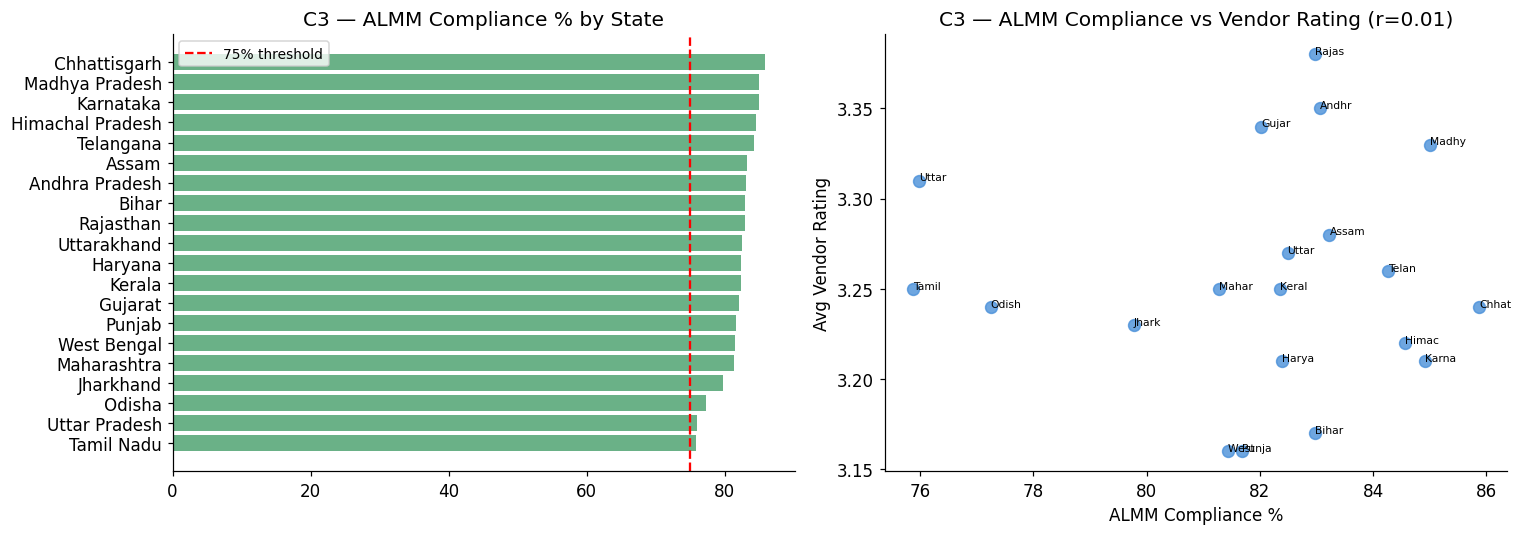

Saved → C3_ALMM_Compliance.png


In [14]:
# C3 
commissioned_c3 = df[df['Commission_Date'].notna()].copy()

state_almm = (
    commissioned_c3.groupby('State')
    .agg(
        ALMM_Compliance_Pct = ('ALMM_Compliant', lambda x: x.mean() * 100),
        Avg_Vendor_Rating   = ('Vendor_Rating', 'mean'),
        Count               = ('Application_ID', 'count')
    )
    .round(2)
    .reset_index()
    .sort_values('ALMM_Compliance_Pct')
)

below_75 = state_almm[state_almm['ALMM_Compliance_Pct'] < 75]
print('States with ALMM compliance < 75%:')
print(below_75[['State','ALMM_Compliance_Pct','Avg_Vendor_Rating']].to_string(index=False))

corr = state_almm[['ALMM_Compliance_Pct','Avg_Vendor_Rating']].corr().iloc[0,1]
print(f'\nCorrelation ALMM compliance vs Vendor Rating: {corr:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e05c5c' if v < 75 else '#6ab187' for v in state_almm['ALMM_Compliance_Pct']]
axes[0].barh(state_almm['State'], state_almm['ALMM_Compliance_Pct'], color=colors)
axes[0].axvline(75, color='red', linestyle='--', label='75% threshold')
axes[0].set_title('C3 — ALMM Compliance % by State')
axes[0].legend(fontsize=9)

axes[1].scatter(state_almm['ALMM_Compliance_Pct'], state_almm['Avg_Vendor_Rating'],
                color='#4a90d9', s=60, alpha=0.8)
for _, row in state_almm.iterrows():
    axes[1].annotate(row['State'][:5], (row['ALMM_Compliance_Pct'], row['Avg_Vendor_Rating']), fontsize=7)
axes[1].set_xlabel('ALMM Compliance %')
axes[1].set_ylabel('Avg Vendor Rating')
axes[1].set_title(f'C3 — ALMM Compliance vs Vendor Rating (r={corr:.2f})')
plt.tight_layout()
plt.savefig('C3_ALMM_Compliance.png', bbox_inches='tight')
plt.show()
print('Saved → C3_ALMM_Compliance.png')

### C4 — Grievance Analysis

Total grievances: 1,419

(a) Grievance Type Distribution:
Grievance_Type
Delayed CFA            238
Subsidy calculation    217
Portal error           203
Vendor quality         200
Net meter issue        197
Installation delay     185
Loan rejection         179

(b+c) Resolution Rate & SLA Compliance per Type:
     Grievance_Type  Total  Resolved  Avg_TAT_Days  Resolution_Rate_Pct  Pct_Within_SLA
        Delayed CFA    238     181.0          49.8                 76.1            28.6
 Installation delay    185     128.0          52.4                 69.2            27.6
     Loan rejection    179     127.0          50.7                 70.9            28.5
    Net meter issue    197     139.0          45.9                 70.6            30.5
       Portal error    203     150.0          48.2                 73.9            29.1
Subsidy calculation    217     153.0          48.6                 70.5            30.0
     Vendor quality    200     141.0          47.4                 70.5 

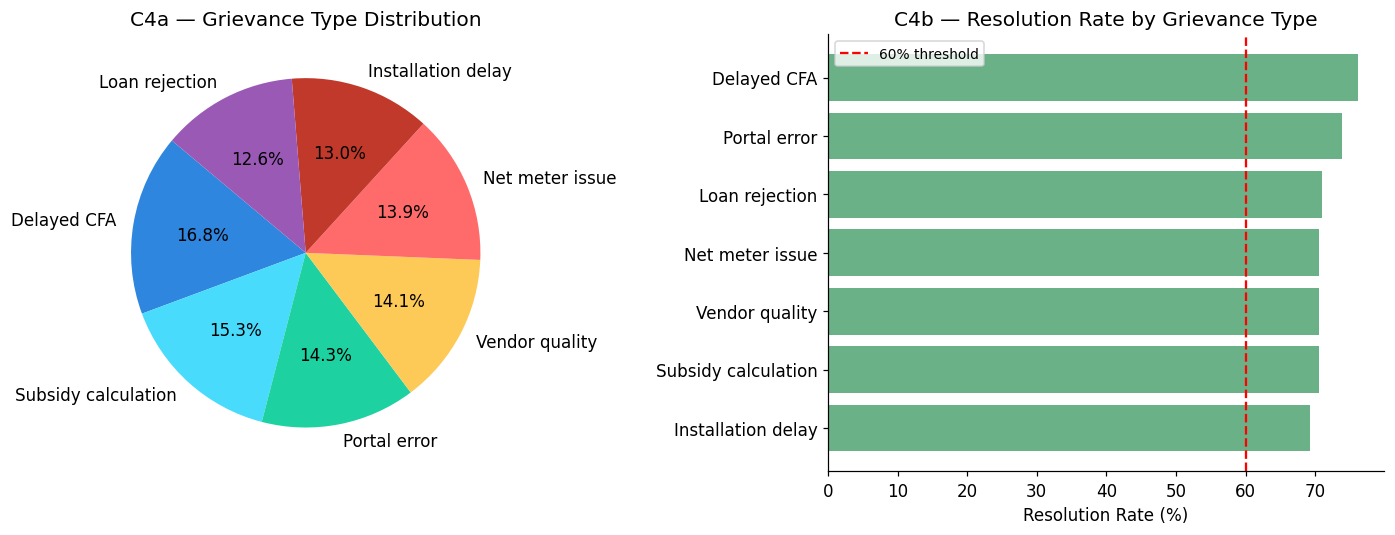

Saved → C4_Grievance_Analysis.png


In [15]:
# C4 
GRIEVANCE_SLA = 30
grievance_df = df[df['Has_Grievance'] == True].copy()
print(f'Total grievances: {len(grievance_df):,}')

# (a) Grievance type distribution
type_counts = grievance_df['Grievance_Type'].value_counts()
print('\n(a) Grievance Type Distribution:')
print(type_counts.to_string())

# (b) Resolution rate per type
resolution = (
    grievance_df.groupby('Grievance_Type')
    .agg(
        Total             = ('Grievance_Resolved','count'),
        Resolved          = ('Grievance_Resolved','sum'),
        Avg_TAT_Days      = ('Grievance_TAT_Days','mean'),
    )
    .reset_index()
)
resolution['Resolution_Rate_Pct'] = (resolution['Resolved'] / resolution['Total'] * 100).round(1)
resolution['Pct_Within_SLA'] = (
    grievance_df.groupby('Grievance_Type')['Grievance_TAT_Days']
    .apply(lambda x: (x <= GRIEVANCE_SLA).mean() * 100)
    .values
)
resolution = resolution.round(1)
print('\n(b+c) Resolution Rate & SLA Compliance per Type:')
print(resolution.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#2e86de','#48dbfb','#1dd1a1','#feca57','#ff6b6b','#c0392b','#9b59b6'],
            startangle=140)
axes[0].set_title('C4a — Grievance Type Distribution')

resolution_s = resolution.sort_values('Resolution_Rate_Pct')
bar_colors = ['#e05c5c' if v < 60 else '#6ab187' for v in resolution_s['Resolution_Rate_Pct']]
axes[1].barh(resolution_s['Grievance_Type'], resolution_s['Resolution_Rate_Pct'], color=bar_colors)
axes[1].axvline(60, color='red', linestyle='--', label='60% threshold')
axes[1].set_xlabel('Resolution Rate (%)')
axes[1].set_title('C4b — Resolution Rate by Grievance Type')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('C4_Grievance_Analysis.png', bbox_inches='tight')
plt.show()
print('Saved → C4_Grievance_Analysis.png')

### C5 — Linear Regression: Predicting Satisfaction Score

Rows used for regression: 3,674

R² = 0.0023
Intercept = 3.3675

Coefficients (standardised — larger |value| = more influence):
                Feature  Coefficient
          Vendor_Rating    -0.032446
         System_Size_kW    -0.022974
     Grievance_Resolved    -0.006775
Monthly_Bill_Savings_Rs     0.005597
    Total_Pipeline_Days     0.024095

Most influential factor: Vendor_Rating (coef=-0.0324)


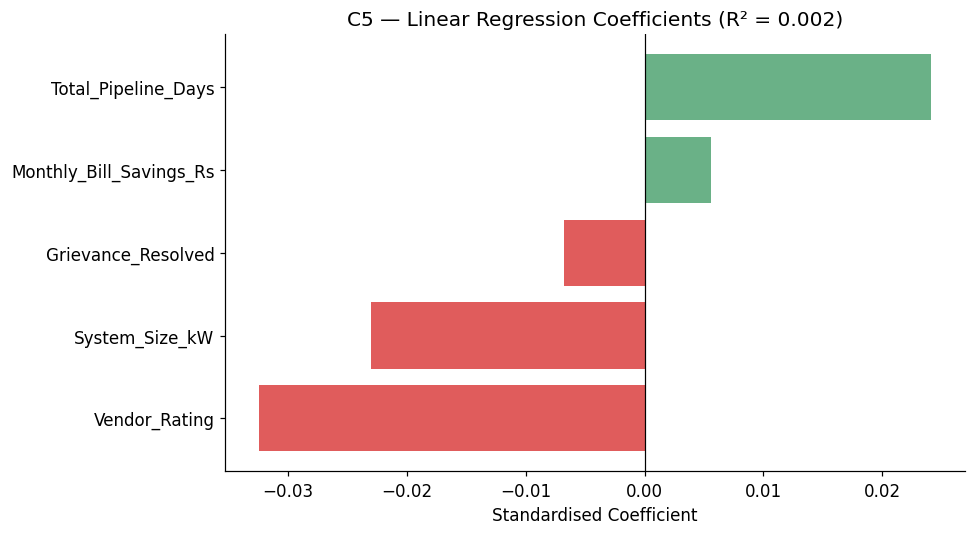

Saved → C5_Regression_Coefficients.png


In [16]:
# C5 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

FEATURES = ['System_Size_kW','Monthly_Bill_Savings_Rs','Vendor_Rating',
            'Grievance_Resolved','Total_Pipeline_Days']
TARGET   = 'Satisfaction_Score'

model_df = df[FEATURES + [TARGET]].copy()
model_df['Grievance_Resolved'] = model_df['Grievance_Resolved'].fillna(0)
model_df = model_df.dropna()
print(f'Rows used for regression: {len(model_df):,}')

X = model_df[FEATURES].values
y = model_df[TARGET].values

# Scale features for comparable coefficients
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)
y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)

coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': model.coef_}).sort_values('Coefficient')
print(f'\nR² = {r2:.4f}')
print(f'Intercept = {model.intercept_:.4f}')
print('\nCoefficients (standardised — larger |value| = more influence):')
print(coef_df.to_string(index=False))
most_influential = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).iloc[0]
print(f'\nMost influential factor: {most_influential["Feature"]} (coef={most_influential["Coefficient"]:.4f})')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#6ab187' if v > 0 else '#e05c5c' for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised Coefficient')
ax.set_title(f'C5 — Linear Regression Coefficients (R² = {r2:.3f})')
plt.tight_layout()
plt.savefig('C5_Regression_Coefficients.png', bbox_inches='tight')
plt.show()
print('Saved → C5_Regression_Coefficients.png')

---
## Section D: Equity & Impact Analysis

### D1 — Beneficiary Category Share vs National Population Share

Beneficiary Category Share in Dataset:
Beneficiary_Category
General         41.08
BPL             20.34
OBC             14.86
SC/ST           14.82
Women-headed     8.90

Combined BPL + SC/ST + Women-headed share in dataset: 44.1%
National population share (assumed):                  55.0%
Gap: -10.9%  → Scheme under-represents marginalised groups


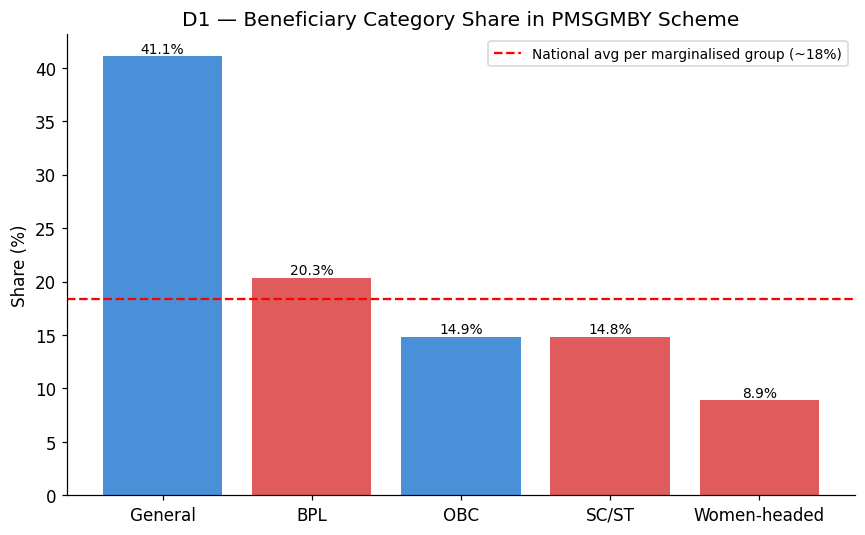

Saved → D1_Beneficiary_Share.png


In [17]:
# D1 
cat_share = (df['Beneficiary_Category'].value_counts(normalize=True) * 100).round(2)
print('Beneficiary Category Share in Dataset:')
print(cat_share.to_string())

marginalised_cats = ['BPL','SC/ST','Women-headed']
marginalised_share = cat_share[marginalised_cats].sum()
NATIONAL_MARGINALISED_PCT = 55.0   # assumed per assignment
print(f'\nCombined BPL + SC/ST + Women-headed share in dataset: {marginalised_share:.1f}%')
print(f'National population share (assumed):                  {NATIONAL_MARGINALISED_PCT:.1f}%')
gap = marginalised_share - NATIONAL_MARGINALISED_PCT
print(f'Gap: {gap:+.1f}%  → Scheme {"over-represents" if gap > 0 else "under-represents"} marginalised groups')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cat_share.index, cat_share.values,
              color=['#e05c5c' if c in marginalised_cats else '#4a90d9' for c in cat_share.index])
for bar, val in zip(bars, cat_share.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
ax.axhline(NATIONAL_MARGINALISED_PCT/len(marginalised_cats), color='red', linestyle='--',
           label=f'National avg per marginalised group (~{NATIONAL_MARGINALISED_PCT/len(marginalised_cats):.0f}%)')
ax.set_ylabel('Share (%)')
ax.set_title('D1 — Beneficiary Category Share in PMSGMBY Scheme')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('D1_Beneficiary_Share.png', bbox_inches='tight')
plt.show()
print('Saved → D1_Beneficiary_Share.png')

### D2 — State-wise Installations, Gini Coefficient & Lorenz Curve

           State  Installations  Share_Pct  Cumulative_Pct
     Uttarakhand            217       5.90            5.90
   Uttar Pradesh            204       5.55           11.45
          Punjab            202       5.50           16.95
  Madhya Pradesh            200       5.44           22.39
       Telangana            197       5.36           27.75
           Bihar            188       5.12           32.87
     Maharashtra            187       5.09           37.96
          Kerala            187       5.09           43.05
    Chhattisgarh            184       5.01           48.06
  Andhra Pradesh            183       4.98           53.04
       Rajasthan            182       4.95           57.99
       Karnataka            179       4.87           62.86
         Gujarat            178       4.84           67.70
       Jharkhand            178       4.84           72.54
         Haryana            176       4.79           77.33
      Tamil Nadu            170       4.63           81.

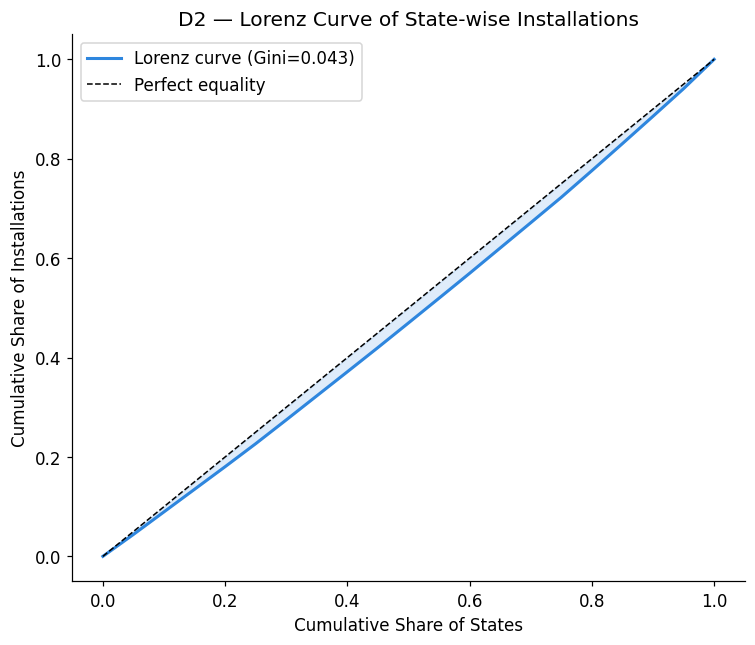

Saved → D2_Lorenz_Curve.png


In [18]:
# D2 
install_by_state = (
    df[df['Commission_Date'].notna()]
    .groupby('State').size()
    .sort_values(ascending=False)
    .reset_index(name='Installations')
)
total_installs = install_by_state['Installations'].sum()
install_by_state['Share_Pct'] = (install_by_state['Installations'] / total_installs * 100).round(2)
install_by_state['Cumulative_Pct'] = install_by_state['Share_Pct'].cumsum().round(2)
print(install_by_state.to_string(index=False))

# States accounting for >50%
cumsum = 0
top_states = []
for _, row in install_by_state.iterrows():
    top_states.append(row['State'])
    cumsum += row['Share_Pct']
    if cumsum >= 50:
        break
print(f'\nStates accounting for >50% of installs: {top_states} ({cumsum:.1f}%)')

# Gini coefficient
def gini(arr):
    arr = np.sort(arr)
    n = len(arr)
    cumulative = np.cumsum(arr)
    return (n + 1 - 2 * cumulative.sum() / cumulative[-1]) / n

gini_val = gini(install_by_state['Installations'].values)
print(f'Gini coefficient: {gini_val:.4f}')

# Lorenz curve
sorted_vals = np.sort(install_by_state['Installations'].values)
cum_share = np.cumsum(sorted_vals) / sorted_vals.sum()
pop_share = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0]+list(pop_share), [0]+list(cum_share), color='#2e86de', linewidth=2, label=f'Lorenz curve (Gini={gini_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect equality')
ax.fill_between([0]+list(pop_share), [0]+list(cum_share), [0]+list(pop_share), alpha=0.15, color='#2e86de')
ax.set_xlabel('Cumulative Share of States')
ax.set_ylabel('Cumulative Share of Installations')
ax.set_title('D2 — Lorenz Curve of State-wise Installations')
ax.legend()
plt.tight_layout()
plt.savefig('D2_Lorenz_Curve.png', bbox_inches='tight')
plt.show()
print('Saved → D2_Lorenz_Curve.png')

### D3 — Performance Efficiency Ratio Heatmap

=== Performance Ratio by State & System Size ===
System_Size_kW        1      2      3
State                                
Andhra Pradesh    0.868  0.884  0.886
Assam             0.851  0.882  0.846
Bihar             0.849  0.849  0.866
Chhattisgarh      0.861  0.853  0.903
Gujarat           0.875  0.884  0.876
Haryana           0.861  0.873  0.903
Himachal Pradesh  0.906  0.856  0.899
Jharkhand         0.871  0.902  0.869
Karnataka         0.920  0.893  0.841
Kerala            0.889  0.831  0.949
Madhya Pradesh    0.869  0.888  0.857
Maharashtra       0.867  0.903  0.884
Odisha            0.835  0.890  0.865
Punjab            0.886  0.875  0.874
Rajasthan         0.873  0.876  0.885
Tamil Nadu        0.861  0.884  0.877
Telangana         0.858  0.876  0.894
Uttar Pradesh     0.874  0.893  0.894
Uttarakhand       0.902  0.883  0.851
West Bengal       0.898  0.895  0.937

Segments underperforming (<85% ratio):
State             System_Size_kW
Andhra Pradesh    1                 21
   

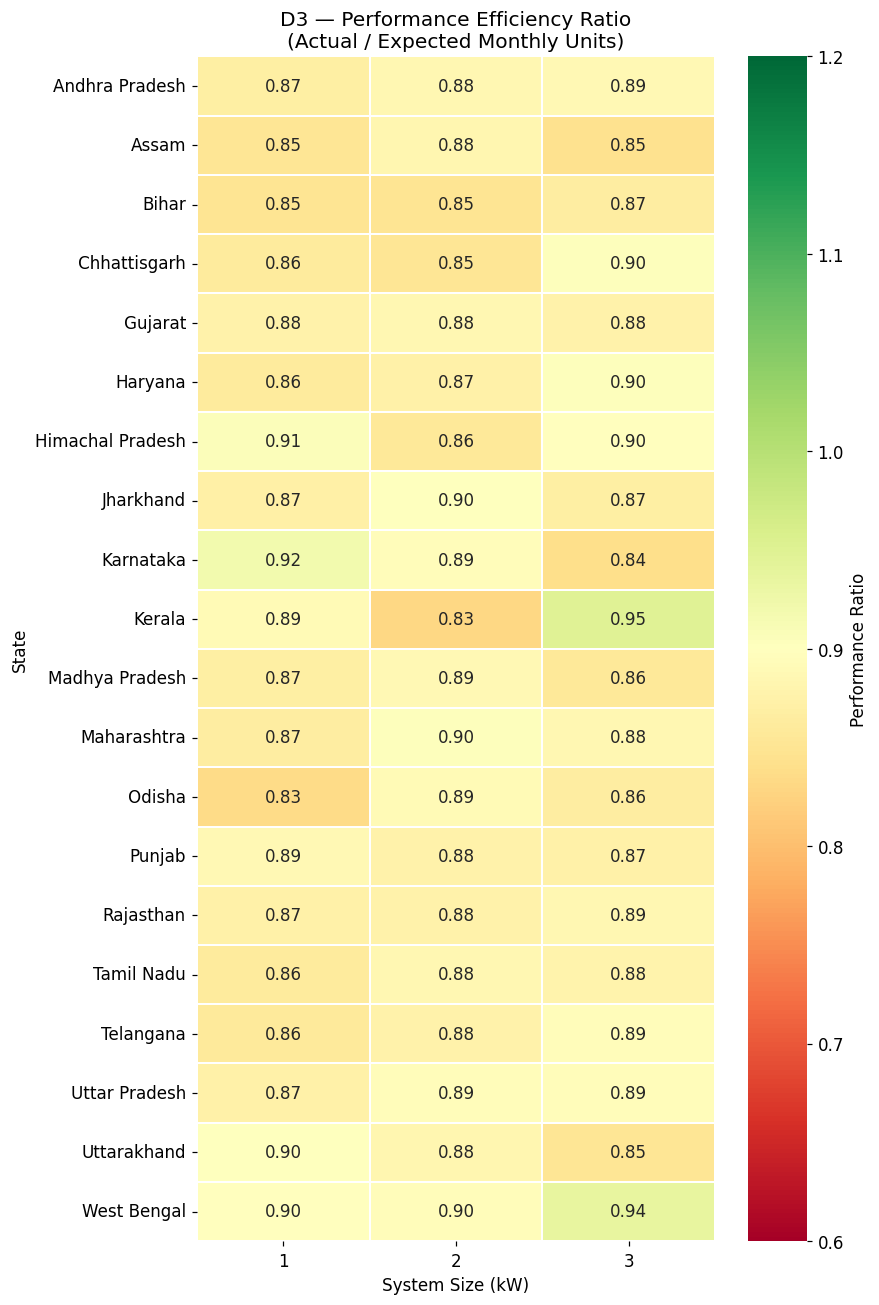

Saved → D3_Performance_Heatmap.png


In [19]:
# D3 
perf_df = df.dropna(subset=['Actual_Monthly_Units']).copy()
perf_df['Performance_Ratio'] = perf_df['Actual_Monthly_Units'] / perf_df['Expected_Monthly_Units']

heatmap_data = (
    perf_df.groupby(['State','System_Size_kW'])['Performance_Ratio']
    .mean()
    .unstack(level='System_Size_kW')
    .round(3)
)

print('=== Performance Ratio by State & System Size ===')
print(heatmap_data.to_string())

under_85 = perf_df[perf_df['Performance_Ratio'] < 0.85].groupby(['State','System_Size_kW']).size()
print(f'\nSegments underperforming (<85% ratio):')
print(under_85[under_85 > 0].to_string() if len(under_85[under_85 > 0]) > 0 else 'None')

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0.6, vmax=1.2, linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Performance Ratio'})
ax.set_title('D3 — Performance Efficiency Ratio\n(Actual / Expected Monthly Units)')
ax.set_xlabel('System Size (kW)')
ax.set_ylabel('State')
plt.tight_layout()
plt.savefig('D3_Performance_Heatmap.png', bbox_inches='tight')
plt.show()
print('Saved → D3_Performance_Heatmap.png')

### D4 — Payback Period by Beneficiary Category

Payback Period Statistics by Beneficiary Category (months):
                      median  mean   min    max
Beneficiary_Category                           
BPL                     39.0  41.6  13.9  112.8
General                 38.5  41.4  10.8  119.3
OBC                     37.7  40.9  11.7  108.5
SC/ST                   36.4  39.2  12.4  100.6
Women-headed            38.0  40.9  14.4  124.6

Median payback — BPL: 39.0 months | General: 38.5 months


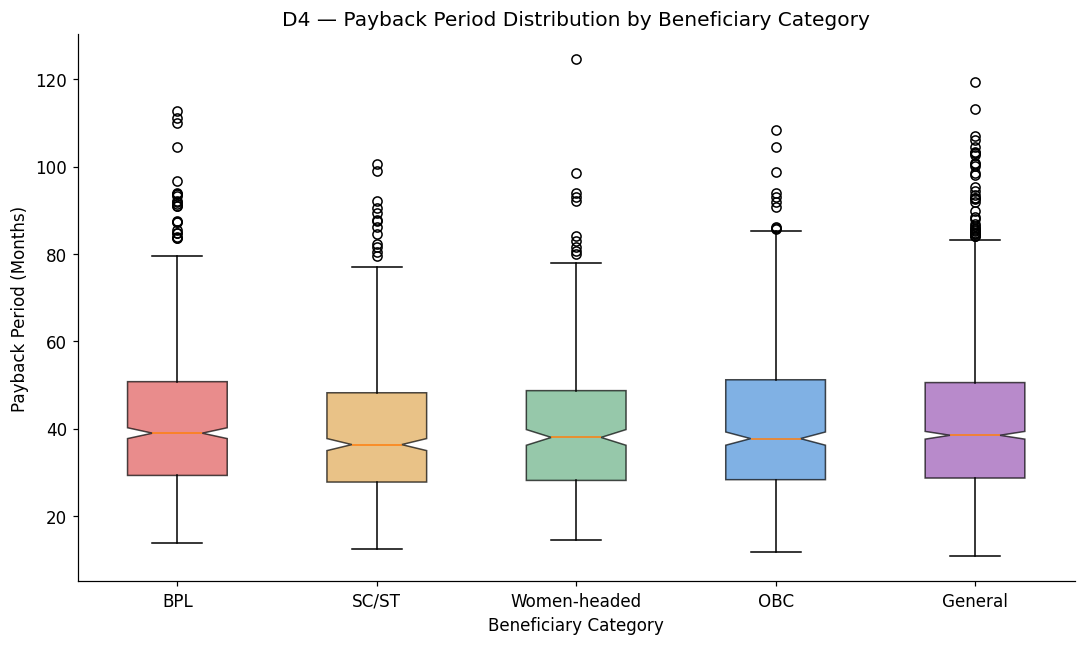

Saved → D4_Payback_Period.png


In [20]:
# D4 
payback_df = df.dropna(subset=['Monthly_Bill_Savings_Rs']).copy()
payback_df = payback_df[payback_df['Monthly_Bill_Savings_Rs'] > 0]
payback_df['Payback_Months'] = (
    (payback_df['Market_Cost_Rs'] - payback_df['CFA_Sanctioned_Rs']) /
    payback_df['Monthly_Bill_Savings_Rs']
)
# Cap unrealistic values (>30 years)
payback_df['Payback_Months'] = payback_df['Payback_Months'].clip(upper=360)

print('Payback Period Statistics by Beneficiary Category (months):')
payback_stats = payback_df.groupby('Beneficiary_Category')['Payback_Months'].agg(
    ['median','mean','min','max']).round(1)
print(payback_stats.to_string())

bpl_median = payback_df[payback_df['Beneficiary_Category']=='BPL']['Payback_Months'].median()
gen_median = payback_df[payback_df['Beneficiary_Category']=='General']['Payback_Months'].median()
print(f'\nMedian payback — BPL: {bpl_median:.1f} months | General: {gen_median:.1f} months')

cat_order = ['BPL','SC/ST','Women-headed','OBC','General']
data_for_box = [payback_df[payback_df['Beneficiary_Category']==c]['Payback_Months'].dropna()
                for c in cat_order if c in payback_df['Beneficiary_Category'].unique()]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(data_for_box, labels=[c for c in cat_order if c in payback_df['Beneficiary_Category'].unique()],
                patch_artist=True, notch=True)
colors_box = ['#e05c5c','#e0a854','#6ab187','#4a90d9','#9b59b6']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel('Beneficiary Category')
ax.set_ylabel('Payback Period (Months)')
ax.set_title('D4 — Payback Period Distribution by Beneficiary Category')
plt.tight_layout()
plt.savefig('D4_Payback_Period.png', bbox_inches='tight')
plt.show()
print('Saved → D4_Payback_Period.png')

---
## Save Final Outputs

In [21]:
# Save the enriched dataframe with all computed columns
df.to_excel('PMSGMBY_Enriched_Dataset.xlsx', index=False)
print('Saved → PMSGMBY_Enriched_Dataset.xlsx')

import os
output_files = [
    'A1_Missing_Data.png', 'A2_Pipeline_Days_Histogram.png',
    'A3_Outlier_Treatment.png', 'A5_Summary_Statistics.xlsx',
    'B1_Market_Cost_Gap.png', 'B2_Interest_Rate_Breach_By_State.png',
    'B3_DISCOM_SLA.xlsx', 'B4_Bill_Savings.png', 'B5_DISCOM_Incentive.png',
    'C1_Pipeline_Funnel.png', 'C2_Pipeline_By_State.png',
    'C3_ALMM_Compliance.png', 'C4_Grievance_Analysis.png',
    'C5_Regression_Coefficients.png', 'D1_Beneficiary_Share.png',
    'D2_Lorenz_Curve.png', 'D3_Performance_Heatmap.png',
    'D4_Payback_Period.png', 'PMSGMBY_Enriched_Dataset.xlsx'
]
print('\n All Output Files ')
for f in output_files:
    status = '✓' if os.path.isfile(f) else '✗'
    print(f'  {status}  {f}')

Saved → PMSGMBY_Enriched_Dataset.xlsx

 All Output Files 
  ✓  A1_Missing_Data.png
  ✓  A2_Pipeline_Days_Histogram.png
  ✓  A3_Outlier_Treatment.png
  ✓  A5_Summary_Statistics.xlsx
  ✓  B1_Market_Cost_Gap.png
  ✗  B2_Interest_Rate_Breach_By_State.png
  ✓  B3_DISCOM_SLA.xlsx
  ✓  B4_Bill_Savings.png
  ✓  B5_DISCOM_Incentive.png
  ✓  C1_Pipeline_Funnel.png
  ✓  C2_Pipeline_By_State.png
  ✓  C3_ALMM_Compliance.png
  ✓  C4_Grievance_Analysis.png
  ✓  C5_Regression_Coefficients.png
  ✓  D1_Beneficiary_Share.png
  ✓  D2_Lorenz_Curve.png
  ✓  D3_Performance_Heatmap.png
  ✓  D4_Payback_Period.png
  ✓  PMSGMBY_Enriched_Dataset.xlsx
